# Plots for figure 3

## Tree
The Tree plot is generated using Itol and is not included in the notebook.
The files to recreate the tree is in Data/figure3

## Thermal Shift Assay (TSA) 
Data from round 3 and round 4 experiments is included

Data is only featured from Lineage 1,2,5 since these were the only active variants, (Lineage 3 WT were not active)

## Relative Activity after heating
Data from round 3

Data from Lineage 1,2,3,4,5

## Kinetics
Data from round 3 variants and MPNN control

Data from Lineage 2 (A0A372IUB3) variants


# Thermal Shift Assay (TSA)

In [1]:
# Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
from Bio import SeqIO
from glob import glob
from scipy.optimize import curve_fit

import sklearn
from scipy.stats import pearsonr, spearmanr

from Helpers.helper_figure3 import *

# Summary TM


In [2]:
File_TM_B3 = "../Data/Figure3/TSA_summary_round3.csv"
File_TM_B4 = "../Data/Figure3/TSA_summary_round4.csv"


In [3]:


df_TM_B3 = pd.read_csv(File_TM_B3)
df_TM_B4 = pd.read_csv(File_TM_B4)

df_TM_B3 = df_TM_B3[["#Annotation", "#Tm"]]
df_TM_B4 = df_TM_B4[["#Annotation", "#Tm"]]


/Users/sandravi/Documents/Projects/THOR_Analysis/Scripts/Helpers/helper_figure3.py:200: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


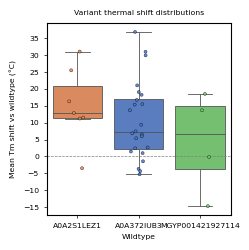

In [4]:
tm_summary_B3, variant_shift_B3 = summarize_tm_shifts(df_TM_B3)
tm_summary_B4, variant_shift_B4 = summarize_tm_shifts(df_TM_B4)


variant_shift_points_B3 = prepare_variant_shift_plot_df(df_TM_B3, "Batch 3")
variant_shift_points_B4 = prepare_variant_shift_plot_df(df_TM_B4, "Batch 4")
variant_shift_plot_df = pd.concat([variant_shift_points_B3, variant_shift_points_B4], ignore_index=True)

split_hues_by_batch = False
plot_size_mm = (60, 60)
plot_font_size = 5.5

plot_variant_shift_boxplot(
    variant_shift_plot_df,
    split_hues_by_batch=split_hues_by_batch,
    size_mm=plot_size_mm,
    font_size=plot_font_size
)
plt.savefig("../Results/Figure3/Box_plot_TM_diff.pdf", bbox_inches="tight")
plt.show()

Batch 3 wildtype / variant pairs loaded from Data/Figure3


,wildtype_id,variant_name,Tm_difference_vs_wildtype,variant_mean_Tm,wildtype_mean_Tm,variant_curve_replicates,wildtype_curve_replicates
0,A0A2S1LEZ1,A0A2S1LEZ1_362,31.028,71.444,40.416,3,3
1,A0A372IUB3,A0A372IUB3_1847,36.835,92.292,55.457,3,3
2,MGYP001421927114,MGYP001421927114_1344,18.507,67.334,48.827,3,3


,wildtype_id,sample_type,sample_name,replicate_id,Tm,R_square,curve_file
0,A0A2S1LEZ1,Wildtype,A0A2S1LEZ1,1,40.175,0.9991,A0A2S1LEZ1_rep1.txt
1,A0A2S1LEZ1,Wildtype,A0A2S1LEZ1,2,40.434,0.9985,A0A2S1LEZ1_rep2.txt
2,A0A2S1LEZ1,Wildtype,A0A2S1LEZ1,3,40.640,0.9976,A0A2S1LEZ1_rep3.txt
3,A0A2S1LEZ1,Best variant,A0A2S1LEZ1_362,1,71.662,0.9795,A0A2S1LEZ1_362_rep1.txt
4,A0A2S1LEZ1,Best variant,A0A2S1LEZ1_362,2,71.342,0.9849,A0A2S1LEZ1_362_rep2.txt
5,A0A2S1LEZ1,Best variant,A0A2S1LEZ1_362,3,71.328,0.9836,A0A2S1LEZ1_362_rep3.txt
6,A0A372IUB3,Wildtype,A0A372IUB3,1,56.823,0.9963,A0A372IUB3_rep1.txt
7,A0A372IUB3,Wildtype,A0A372IUB3,2,55.912,0.9947,A0A372IUB3_rep2.txt
8,A0A372IUB3,Wildtype,A0A372IUB3,3,53.636,0.9984,A0A372IUB3_rep3.txt
9,A0A372IUB3,Best variant,A0A372IUB3_1847,1,92.405,0.9983,A0A372IUB3_1847_rep1.txt


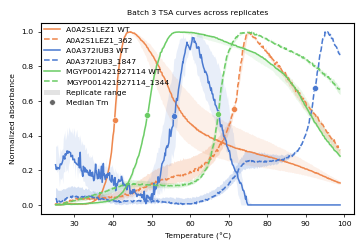

In [5]:
result_summary_B3_full = pd.read_csv(File_TM_B3)
curve_dir_B3 = os.path.dirname(File_TM_B3)

curve_pairs_B3, curve_replicates_B3, curve_data_B3 = prepare_tsa_curve_data_from_directory(
    curve_dir_B3,
    result_summary_B3_full
)

print("Batch 3 wildtype / variant pairs loaded from Data/Figure3")
display(
    curve_pairs_B3[[
        "wildtype_id",
        "variant_name",
        "Tm_difference_vs_wildtype",
        "variant_mean_Tm",
        "wildtype_mean_Tm",
        "variant_curve_replicates",
        "wildtype_curve_replicates"
    ]].round(3)
)

display(
    curve_replicates_B3[[
        "wildtype_id",
        "sample_type",
        "sample_name",
        "replicate_id",
        "Tm",
        "R_square",
        "curve_file"
    ]].round({"Tm": 3, "R_square": 4})
)

curve_plot_size_mm = (89, 60)
curve_plot_font_size = 5.5

plot_tsa_replicate_bands(
    curve_data_B3,
    curve_pairs_B3,
    size_mm=curve_plot_size_mm,
    font_size=curve_plot_font_size,
    title="Batch 3 TSA curves across replicates"
)
plt.savefig("../Results/Figure3/Best_variants_melting_curves.pdf", bbox_inches="tight")
plt.show()

# Activity resistance analysis

temperature_c,30,40,50,60,70,80,90,100
sample_name,,,,,,,,
A0A2S1LEZ1,7.0,181.2,100.0,5.0,29.7,79.1,2.7,58.2
A0A2S1LEZ1_337,304.5,185.6,100.0,69.3,24.8,3.1,8.5,0.0
A0A2S1LEZ1_344,187.1,175.7,100.0,0.0,25.2,21.7,12.6,0.0
A0A2S1LEZ1_349,365.5,208.2,100.0,43.4,157.8,132.8,3.2,7.6
A0A2S1LEZ1_362,205.4,97.1,100.0,96.4,62.8,12.2,14.0,5.5
A0A372IUB3,31.3,33.0,100.0,180.3,135.3,28.0,11.2,11.9
A0A372IUB3_103,1.7,62.6,100.0,16.9,188.5,28.0,15.0,38.6
A0A372IUB3_104,38.0,79.1,100.0,108.0,116.4,8.3,2.2,0.0
A0A372IUB3_106,17.0,7.0,100.0,1597.3,1868.2,187.5,81.1,39.4


Wildtype temperature at which relative activity first drops below the retained activity threshold


,wildtype_id,last_temperature_retained_c,percent_active_at_last_retained,first_temperature_below_threshold_c,percent_active_at_first_loss,retained_activity_threshold,evaluated_from_temperature_c,status
0,A0A2S1LEZ1,100.0,58.2,60.0,5.0,50.0,50.0,first tested temperature below threshold shown
1,A0A372IUB3,70.0,135.3,80.0,28.0,50.0,50.0,first tested temperature below threshold shown
2,MGYP001421927114,90.0,107.5,100.0,48.5,50.0,50.0,first tested temperature below threshold shown


Percent substrate catalyzed based on the lowest observed signal in each trace (threshold = 12%)


temperature_c,30,40,50,60,70,80,90,100
sample_name,,,,,,,,
A0A2S1LEZ1,90.0,94.5,42.1,6.9,1.6,1.6,4.4,5.5
A0A2S1LEZ1_337,95.8,89.9,64.1,37.1,6.4,0.1,5.0,8.6
A0A2S1LEZ1_344,67.8,47.7,36.4,8.6,3.9,0.3,5.6,6.0
A0A2S1LEZ1_349,56.5,30.2,10.2,5.7,2.8,0.3,3.7,7.0
A0A2S1LEZ1_362,92.1,79.0,87.9,81.6,45.0,0.0,3.9,2.4
A0A372IUB3,88.9,93.0,94.5,48.4,33.9,0.4,1.6,1.8
A0A372IUB3_103,93.6,93.3,91.0,96.0,91.8,2.5,7.0,0.6
A0A372IUB3_104,94.9,90.8,92.3,91.0,89.4,0.4,2.6,0.0
A0A372IUB3_106,99.0,99.4,98.6,92.7,92.3,16.5,6.5,1.5


Wildtype temperature at which substrate conversion first drops below the activity requirement


,wildtype_id,last_temperature_meeting_conversion_threshold_c,percent_substrate_catalyzed_at_last_retained,first_temperature_below_conversion_threshold_c,percent_substrate_catalyzed_at_first_loss,substrate_conversion_threshold,evaluated_from_temperature_c,status
0,A0A2S1LEZ1,50.0,42.1,60.0,6.9,12.0,50.0,first tested temperature below threshold shown
1,A0A372IUB3,70.0,33.9,80.0,0.4,12.0,50.0,first tested temperature below threshold shown
2,MGYP001421927114,100.0,80.5,NaN,NaN,12.0,50.0,meets threshold through highest tested tempera...


,wildtype_id,temperature_c,n_variants_measured,n_variants_retained,percent_variants_retained,retained_activity_threshold
0,A0A2S1LEZ1,30,4,4,100.0,50.0
1,A0A2S1LEZ1,40,4,4,100.0,50.0
2,A0A2S1LEZ1,50,4,4,100.0,50.0
3,A0A2S1LEZ1,60,4,2,50.0,50.0
4,A0A2S1LEZ1,70,4,2,50.0,50.0
5,A0A2S1LEZ1,80,4,1,25.0,50.0
6,A0A2S1LEZ1,90,4,0,0.0,50.0
7,A0A2S1LEZ1,100,4,0,0.0,50.0
8,A0A372IUB3,30,20,7,35.0,50.0
9,A0A372IUB3,40,20,13,65.0,50.0


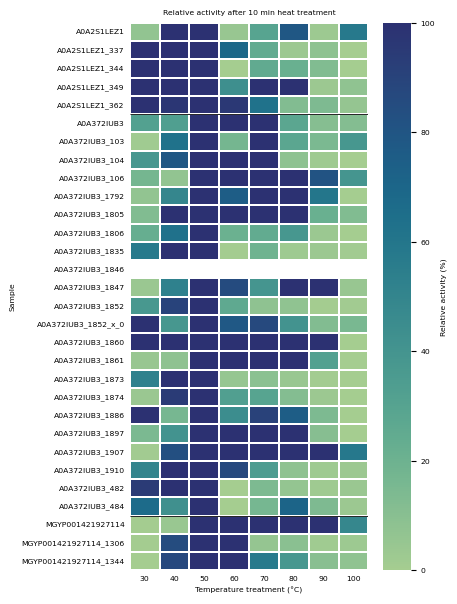

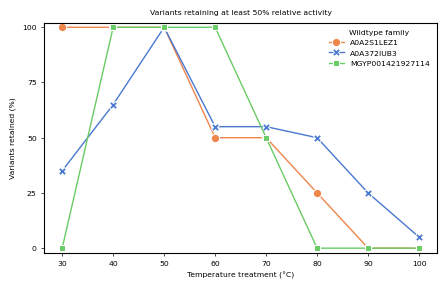

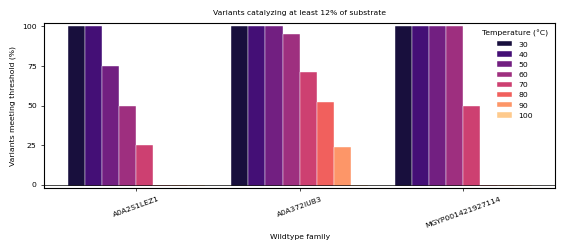

In [6]:
Activity_resistance_B3_dir = "../Data/Figure3"

# Several sequences are more active after mild heating than at 30 C,
# so "max" is the safer default reference for percent activity.
activity_fit_until_s = 540
activity_reference_mode = "temperature" #"max"
activity_reference_temperature = 50

activity_replicates_B3, activity_summary_B3, activity_percent_active_B3 = compile_activity_resistance(
    Activity_resistance_B3_dir,
    fit_until_s=activity_fit_until_s,
    reference_mode=activity_reference_mode,
    reference_temperature=activity_reference_temperature
)

display(activity_percent_active_B3.round(1))

activity_heatmap_size_mm = (110, 150)
activity_font_size = 5.5
retained_activity_threshold = 50
substrate_conversion_threshold = 12
threshold_evaluation_min_temperature = (
    activity_reference_temperature if activity_reference_mode == "temperature" else None
)

wildtype_threshold_loss_B3 = summarize_wildtype_threshold_loss(
    activity_summary_B3,
    retained_activity_threshold=retained_activity_threshold,
    minimum_temperature_c=threshold_evaluation_min_temperature
)

wildtype_conversion_loss_B3 = summarize_wildtype_conversion_loss(
    activity_summary_B3,
    substrate_conversion_threshold=substrate_conversion_threshold,
    minimum_temperature_c=threshold_evaluation_min_temperature
)

print("Wildtype temperature at which relative activity first drops below the retained activity threshold")
display(wildtype_threshold_loss_B3.round(1))

activity_percent_substrate_catalyzed_B3 = (
    activity_summary_B3.pivot(index="sample_name", columns="temperature_c", values="percent_substrate_catalyzed")
    .reindex(index=activity_percent_active_B3.index, columns=activity_percent_active_B3.columns)
)

print(f"Percent substrate catalyzed based on the lowest observed signal in each trace (threshold = {substrate_conversion_threshold}%)")
display(activity_percent_substrate_catalyzed_B3.round(1))

print("Wildtype temperature at which substrate conversion first drops below the activity requirement")
display(wildtype_conversion_loss_B3.round(1))


plot_activity_resistance_heatmap(
    activity_percent_active_B3,
    size_mm=activity_heatmap_size_mm,
    font_size=activity_font_size
)

variant_retention_summary_B3 = summarize_variant_retention_by_wildtype(
    activity_summary_B3,
    retained_activity_threshold=retained_activity_threshold,
    include_wildtypes=False
)

variant_conversion_summary_B3 = summarize_variant_retention_by_wildtype(
    activity_summary_B3,
    retained_activity_threshold=substrate_conversion_threshold,
    include_wildtypes=False,
    activity_metric_column="percent_substrate_catalyzed",
    retained_flag_column="retained_by_substrate_conversion",
    threshold_column_name="substrate_conversion_threshold"
)

display(variant_retention_summary_B3.round(1))

plot_variant_retention_by_wildtype(
    variant_retention_summary_B3,
    retained_activity_threshold=retained_activity_threshold,
    size_mm=(110, 70),
    font_size=activity_font_size
)

plot_variant_retention_bar_by_wildtype(
    variant_conversion_summary_B3,
    retained_activity_threshold=substrate_conversion_threshold,
    size_mm=(140, 60),
    font_size=activity_font_size,
    retained_quantity_label="of substrate"
)
plt.savefig("../Results/Figure3/fraction_active_round3.pdf", bbox_inches = "tight")
plt.show()

# Kinetics
Batch 5 kinetics analysis from a clean local workflow based on `kinetics.xlsx`.

It loads the raw table, converts the NADH slope to rate, fits Michaelis-Menten curves for each enzyme and temperature, and then:
- plots one rate-curve figure per temperature with independent axis scaling
- shows fitted `Km` and `kcat` values in tables
- keeps any row exclusions editable in the execution cell so obvious outliers can be removed cleanly

The enzyme concentration and molecular weight assumptions are collected in one editable table in the execution cell.

,Enzyme,Display_name,Variant_group,Temperature_label,n_points,n_substrate_levels,Vmax_mM_per_s,Km_mM,kcat_s^-1,kcat_over_Km,bootstrap_n_success,r_squared,enzyme_ng_per_uL,MW_g_per_mol
0,WT,WT,Wild type,30 °C,30,10,0.000167,0.036128,11.450760,316.952943,1000,0.749318,0.5,34191.0
1,1792,1792,ThermoGAN variant,30 °C,18,6,0.000455,0.057275,31.050806,542.137915,1000,0.849375,0.5,34140.0
2,1847,1847,ThermoGAN variant,30 °C,27,9,0.000238,0.156472,16.204526,103.562097,1000,0.952497,0.5,34081.0
3,MPNN70,MPNN70,Control variant,30 °C,36,12,0.000058,0.011156,0.968735,86.832553,1000,0.648292,2.0,33461.0
4,WT,WT,Wild type,70 °C,27,9,0.000945,0.076629,64.639872,843.548196,1000,0.909032,0.5,34191.0
5,1792,1792,ThermoGAN variant,70 °C,18,6,0.001254,0.186415,85.595615,459.167240,1000,0.954508,0.5,34140.0
6,1847,1847,ThermoGAN variant,70 °C,39,13,0.000567,0.166866,38.622262,231.457411,1000,0.956466,0.5,34081.0
7,MPNN70,MPNN70,Control variant,70 °C,42,14,0.000305,0.015061,5.096443,338.376404,1000,0.774571,2.0,33461.0
8,WT,WT,Wild type,90 °C,32,10,0.000148,0.064638,10.102451,156.292581,1000,0.778051,0.5,34191.0
9,1792,1792,ThermoGAN variant,90 °C,24,8,0.000395,0.074734,26.988231,361.123584,1000,0.972760,0.5,34140.0


Temperature_label,30 °C,70 °C,90 °C
Display_name,,,
WT,0.0361,0.0766,0.0646
1792,0.0573,0.1864,0.0747
1847,0.1565,0.1669,0.5192
MPNN70,0.0112,0.0151,0.0305


Temperature_label,30 °C,70 °C,90 °C
Display_name,,,
WT,11.451,64.640,10.102
1792,31.051,85.596,26.988
1847,16.205,38.622,19.335
MPNN70,0.969,5.096,1.757


Temperature_label,30 °C,70 °C,90 °C
Display_name,,,
WT,316.953,843.548,156.293
1792,542.138,459.167,361.124
1847,103.562,231.457,37.240
MPNN70,86.833,338.376,57.679


,Km (mM),kcat (s^-1),kcat/Km (mM^-1 s^-1)
Variant,,,
WT,0.0361 ± 0.0299,11.451 ± 2.082,316.953 ± 365.878
1792,0.0573 ± 0.0129,31.051 ± 3.429,542.138 ± 147.338
1847,0.1565 ± 0.0981,16.205 ± 6.966,103.562 ± 16.844
MPNN70,0.0112 ± 3.22e+04,0.969 ± 1.72e+05,86.833 ± 4.00e+18


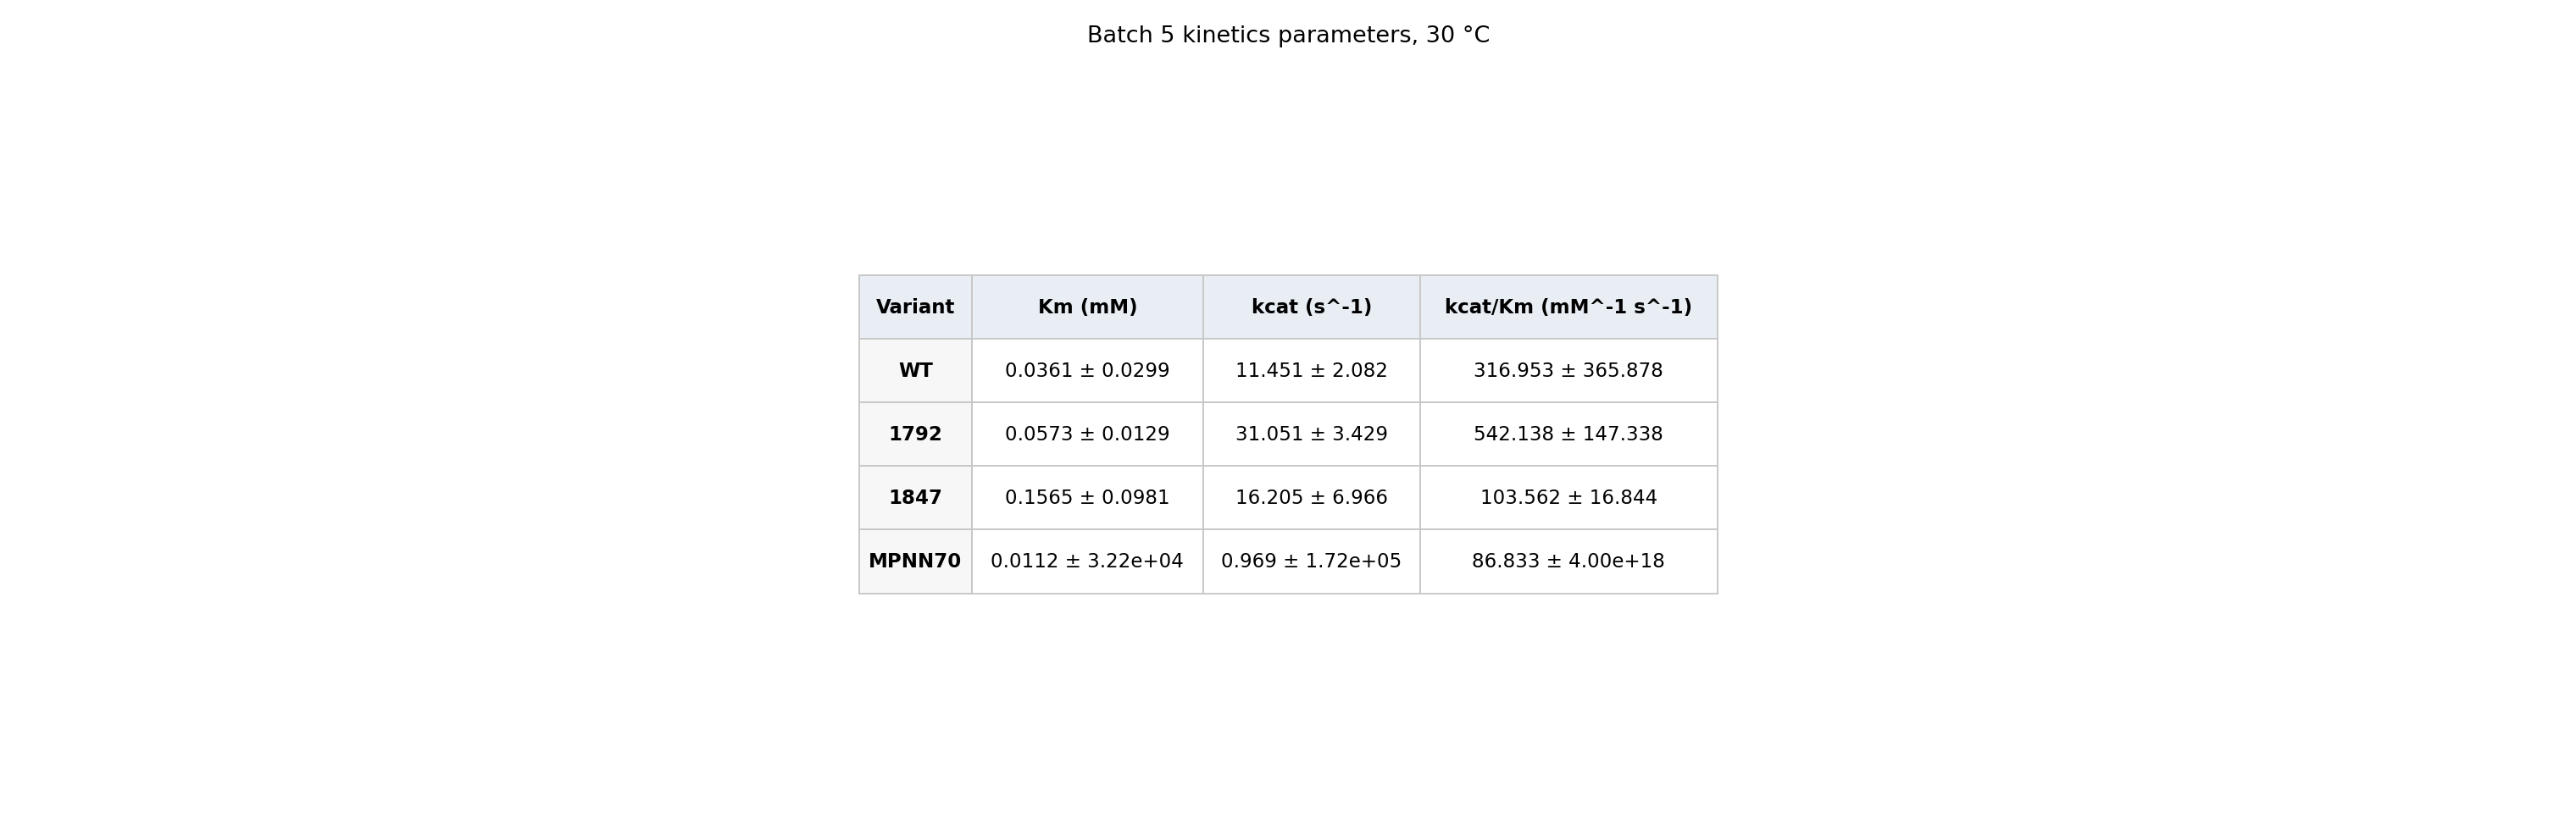

,Km (mM),kcat (s^-1),kcat/Km (mM^-1 s^-1)
Variant,,,
WT,0.0766 ± 0.0413,64.640 ± 10.733,843.548 ± 325.002
1792,0.1864 ± 0.2148,85.596 ± 24.512,459.167 ± 68.069
1847,0.1669 ± 1.09e+05,38.622 ± 1.41e+07,231.457 ± 33.921
MPNN70,0.0151 ± 1.48e+04,5.096 ± 3.31e+05,338.376 ± 9.71e+20


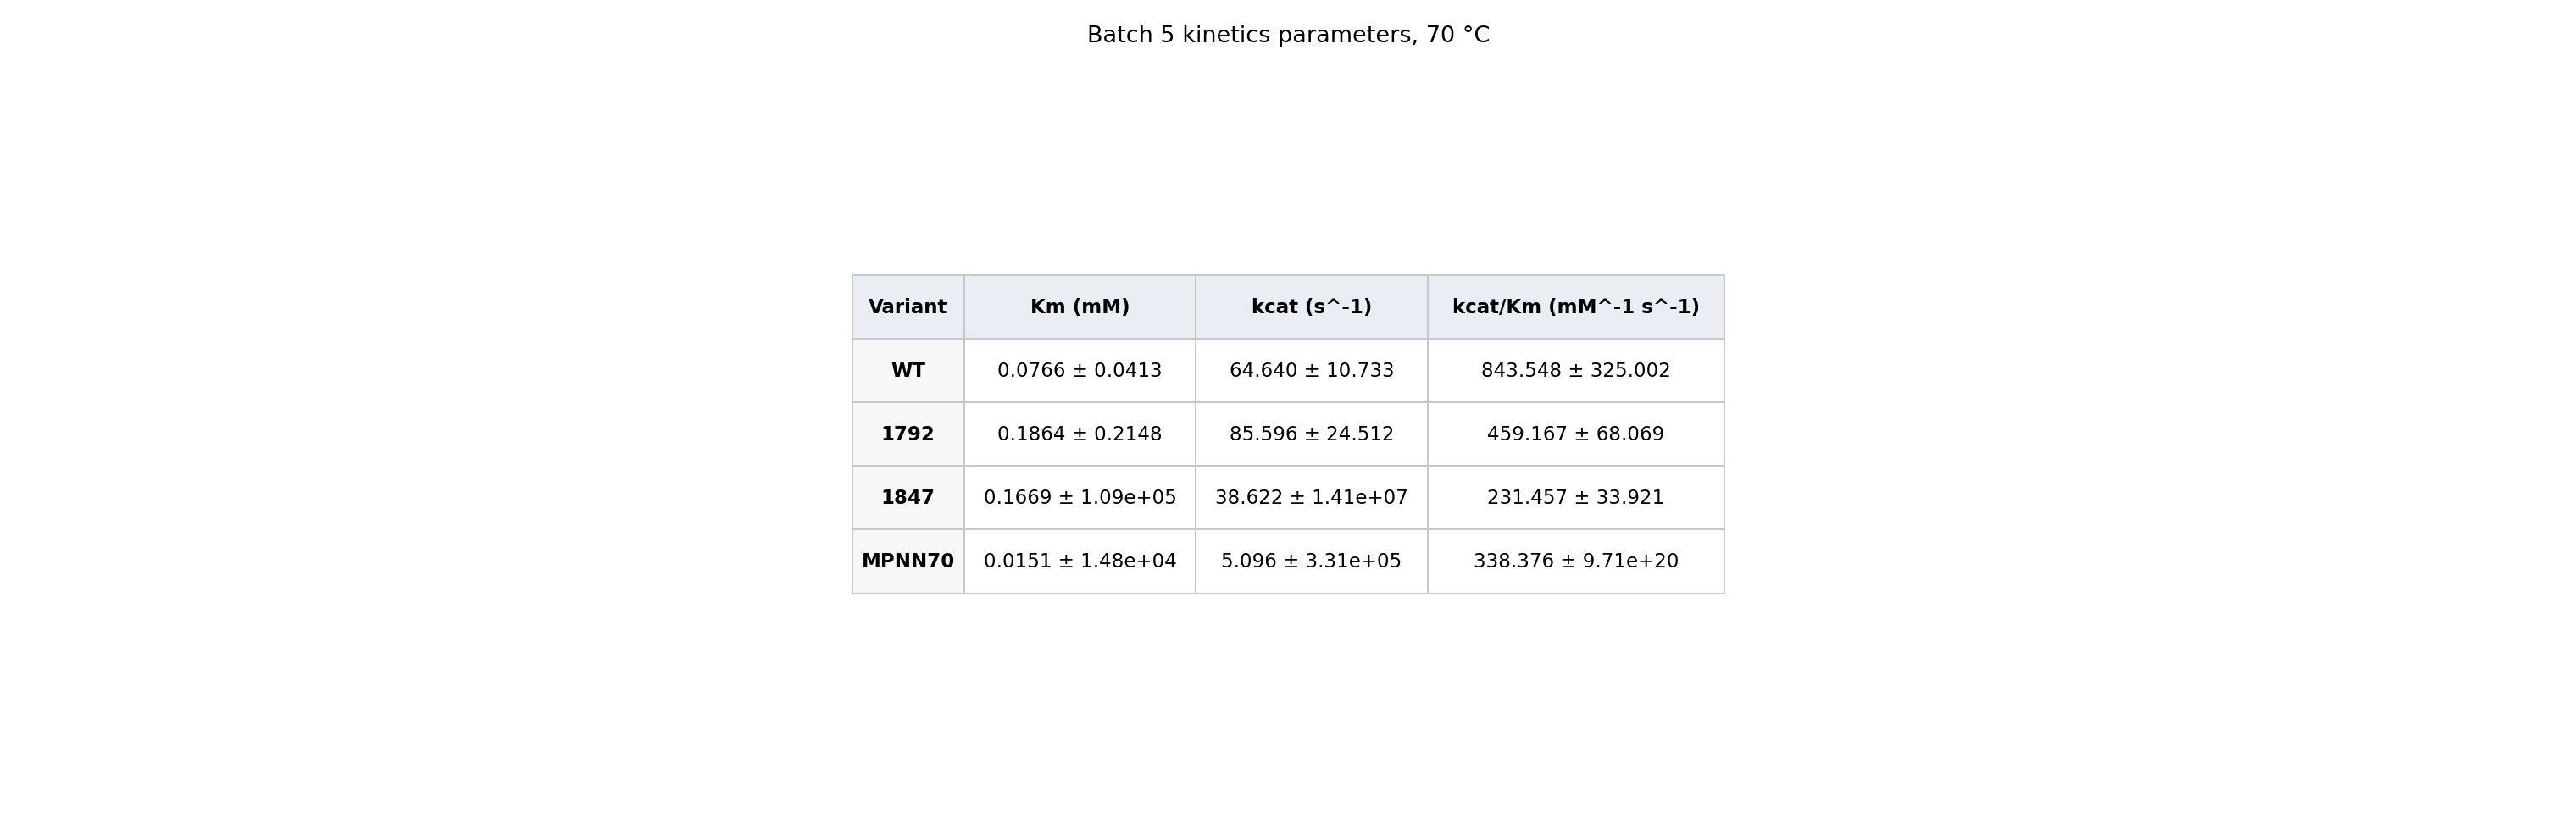

,Km (mM),kcat (s^-1),kcat/Km (mM^-1 s^-1)
Variant,,,
WT,0.0646 ± 0.1297,10.102 ± 2.968,156.293 ± 1.47e+18
1792,0.0747 ± 0.0090,26.988 ± 0.523,361.124 ± 34.919
1847,0.5192 ± 0.0994,19.335 ± 1.817,37.240 ± 5.196
MPNN70,0.0305 ± 0.0151,1.757 ± 0.162,57.679 ± 29.214


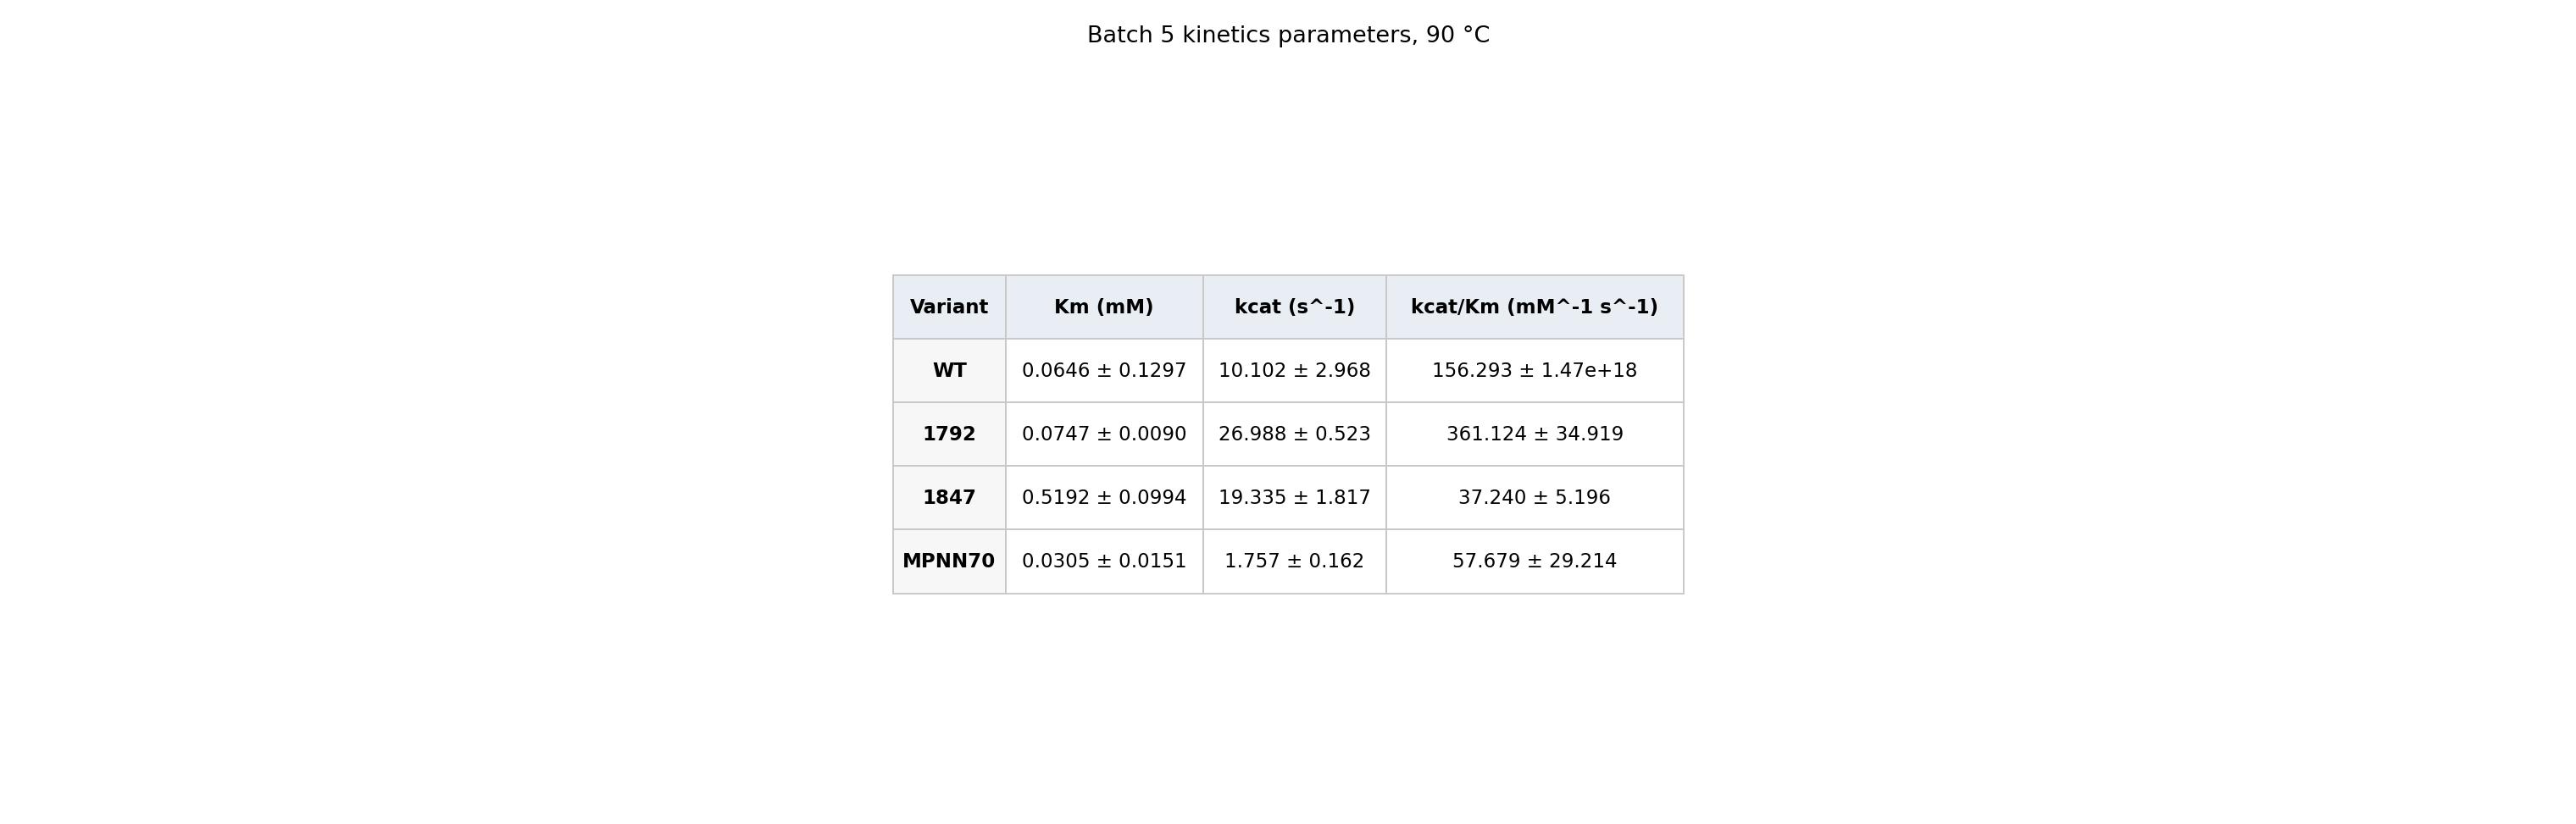

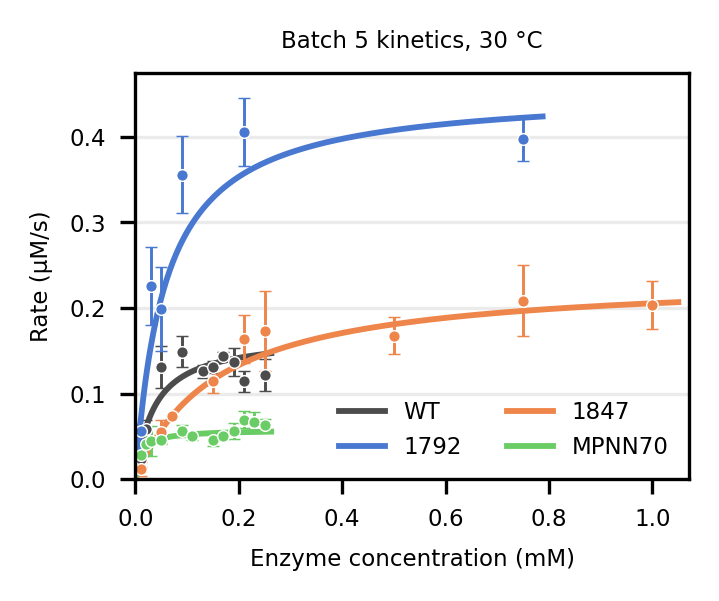

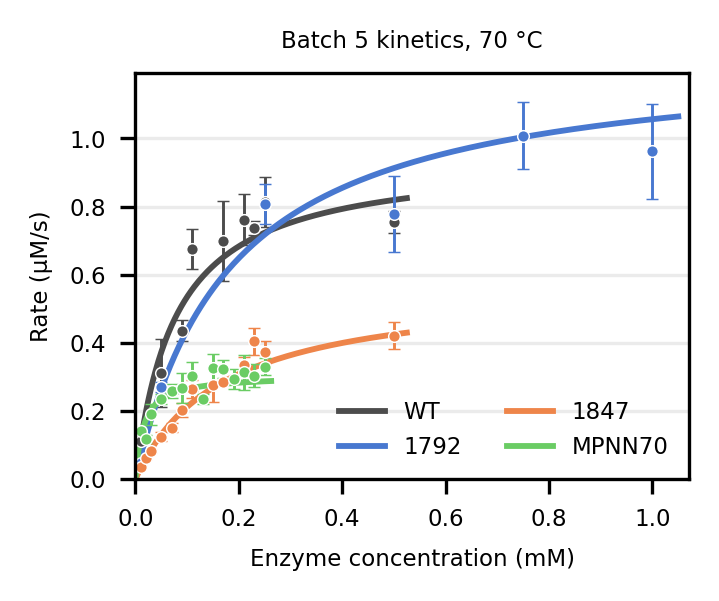

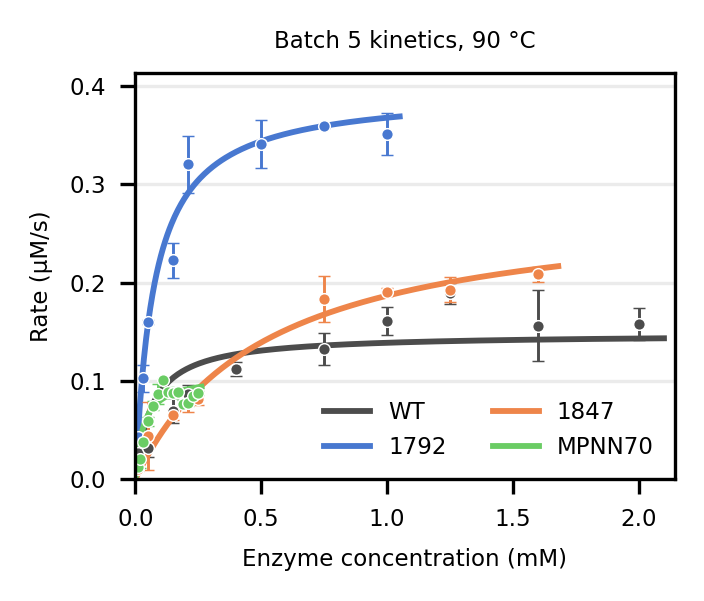

In [7]:
kinetics_xlsx_path = Path(
    "../Data/Figure3/kinetics.xlsx"
)

curve_plot_size_mm = (60, 50)
plot_font_size = 5.5
rate_plot_scale = 1000.0
rate_plot_unit = "µM/s"
parameter_table_specs = [
    ("Km_mM", "Km (mM)", 4),
    ("kcat_s^-1", "kcat (s^-1)", 3),
    ("kcat_over_Km", "kcat/Km (mM^-1 s^-1)", 3),
]
bootstrap_iterations = 1000
bootstrap_ci_percent = 95
parameter_table_uncertainty_mode = "sd" # "ci"
parameter_table_pdf_path = Path("../Results/Figure3/Batch5_kinetics_parameter_summary.pdf")
parameter_table_size_mm = (260, 85)
parameter_table_font_size = 5.5

# Remove the obvious duplicate high-rate rows for 1847 at 90 °C.
# Set this list to [] if you want to include every raw row again.
row_exclusions = [
    {
        "Enzyme": "1847",
        "Temperature": 90.0,
        "Content_mM": 1.6,
        "Replicate": 1.0,
        "Slope_AperS": -0.0060,
    },
    {
        "Enzyme": "1847",
        "Temperature": 90.0,
        "Content_mM": 1.6,
        "Replicate": 1.0,
        "Slope_AperS": -0.0056,
    },
]

enzyme_metadata = [
    {
        "Enzyme": "WT",
        "Display_name": "WT",
        "Variant_group": "Wild type",
        "Color": "#4C4C4C",
        "enzyme_ng_per_uL": 0.5,
        "MW_g_per_mol": 34191.0,
    },
    {
        "Enzyme": "1792",
        "Display_name": "1792",
        "Variant_group": "ThermoGAN variant",
        "Color": "#4878D0",
        "enzyme_ng_per_uL": 0.5,
        "MW_g_per_mol": 34140.0,
    },
    {
        "Enzyme": "1847",
        "Display_name": "1847",
        "Variant_group": "ThermoGAN variant",
        "Color": "#EE854A",
        "enzyme_ng_per_uL": 0.5,
        "MW_g_per_mol": 34081.0,
    },
    {
        "Enzyme": "MPNN70",
        "Display_name": "MPNN70",
        "Variant_group": "Control variant",
        "Color": "#6ACC64",
        "enzyme_ng_per_uL": 2.0,
        "MW_g_per_mol": 33461.0,
    },
]

batch5_kinetics = load_batch5_kinetics(kinetics_xlsx_path)
positive_slope_rows_B5, mixed_sign_groups_B5 = inspect_kinetics_slope_signs(batch5_kinetics)

if not positive_slope_rows_B5.empty:
    print("Potential sign issues: positive slopes produce negative rates and often indicate copied sign errors.")
    display(
        positive_slope_rows_B5[
            ["Enzyme", "Temperature_label", "Content_mM", "Replicate", "Slope_AperS", "v_mMperS"]
        ]
    )

if not mixed_sign_groups_B5.empty:
    print("Replicate groups with mixed slope signs:")
    display(mixed_sign_groups_B5)

batch5_kinetics_filtered, excluded_rows_B5 = exclude_kinetics_rows(batch5_kinetics, row_exclusions)
fit_summary_B5, mean_points_B5, fit_curves_B5 = fit_all_kinetics(
    batch5_kinetics_filtered,
    enzyme_metadata,
    bootstrap_iterations=bootstrap_iterations,
    bootstrap_ci_percent=bootstrap_ci_percent,
)

if not excluded_rows_B5.empty:
    display(
        excluded_rows_B5[
            ["Enzyme", "Temperature_label", "Content_mM", "Replicate", "Slope_AperS", "v_mMperS"]
        ].sort_values(["Temperature_label", "Enzyme", "Content_mM", "Replicate", "Slope_AperS"])
    )

summary_columns = [
    "Enzyme",
    "Display_name",
    "Variant_group",
    "Temperature_label",
    "n_points",
    "n_substrate_levels",
    "Vmax_mM_per_s",
    "Km_mM",
    "kcat_s^-1",
    "kcat_over_Km",
    "bootstrap_n_success",
    "r_squared",
    "enzyme_ng_per_uL",
    "MW_g_per_mol",
]
display(fit_summary_B5[summary_columns])

km_table_B5 = build_parameter_table(fit_summary_B5, value_column="Km_mM", enzyme_metadata=enzyme_metadata).round(4)
kcat_table_B5 = build_parameter_table(fit_summary_B5, value_column="kcat_s^-1", enzyme_metadata=enzyme_metadata).round(3)
kcat_over_km_table_B5 = build_parameter_table(
    fit_summary_B5,
    value_column="kcat_over_Km",
    enzyme_metadata=enzyme_metadata,
).round(3)
parameter_tables_by_temperature_B5 = build_parameter_display_tables_by_temperature(
    fit_summary_B5,
    enzyme_metadata=enzyme_metadata,
    parameter_specs=parameter_table_specs,
    uncertainty_mode=parameter_table_uncertainty_mode,
)

display(km_table_B5)
display(kcat_table_B5)
display(kcat_over_km_table_B5)

for temperature_label, temperature_table in parameter_tables_by_temperature_B5.items():
    display(temperature_table)
    temperature_slug = temperature_label.replace(" °C", "C").replace(" ", "_").replace("°", "")
    temperature_output_path = parameter_table_pdf_path.with_name(
        f"{parameter_table_pdf_path.stem}_{temperature_slug}{parameter_table_pdf_path.suffix}"
    )
    save_dataframe_table_pdf(
        temperature_table,
        output_path=temperature_output_path,
        title=f"Batch 5 kinetics parameters, {temperature_label}",
        size_mm=parameter_table_size_mm,
        font_size=parameter_table_font_size,
    )

plot_rate_curves_by_temperature(
    mean_points_df=mean_points_B5,
    fit_curve_df=fit_curves_B5,
    fit_summary=fit_summary_B5,
    enzyme_metadata=enzyme_metadata,
    size_mm=curve_plot_size_mm,
    font_size=plot_font_size,
    rate_scale=rate_plot_scale,
    rate_unit=rate_plot_unit,
    output_dir="../Results/Figure3/"
)
